# K-Nearest Neighbors on Diabetes 130-US Hospitals Dataset

This notebook implements **binary** readmission prediction (Readmitted vs. Not Readmitted), aligned with the Glucose Gang guide: explicit removal of 5 features, 60/20/20 split, StandardScaler, GridSearchCV over odd k, and evaluation with confusion matrix, learning curve, and prediction time.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, PredefinedSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_fscore_support
)

DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data_cleaned.csv"
RANDOM_STATE = 42

# Features to remove per Glucose Gang guide (high missing / not useful for KNN)
GUIDE_DROP_COLS = ["weight", "payer_code", "medical_specialty", "max_glu_serum", "A1Cresult"]

In [2]:
# Load data and apply Glucose Gang data cleaning: drop 5 features, then drop rows with any remaining missing.
df = pd.read_csv(DATA_PATH, na_values=["?", "None"], low_memory=False)
print(f"Shape after load: {df.shape}")

# Remove the 5 features identified in the guide
df = df.drop(columns=[c for c in GUIDE_DROP_COLS if c in df.columns], errors="ignore")
print(f"After dropping {GUIDE_DROP_COLS}: {df.shape}")

# Drop rows with any remaining missing values
df = df.dropna()
print(f"After dropna(): {df.shape}")

# Binary target: "Not Readmitted" (0) vs "Readmitted" (1 = <30 or >30 days)
df["readmitted_binary"] = (df["readmitted"] != "NO").astype(int)
print(f"\nBinary target distribution:\n{df['readmitted_binary'].value_counts()}")
print(f"  Not Readmitted (0): {(df['readmitted_binary'] == 0).sum()}")
print(f"  Readmitted (1):     {(df['readmitted_binary'] == 1).sum()}")

Shape after load: (101766, 45)
After dropping ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']: (101766, 43)
After dropna(): (98053, 43)

Binary target distribution:
readmitted_binary
0    52338
1    45715
Name: count, dtype: int64
  Not Readmitted (0): 52338
  Readmitted (1):     45715


In [3]:
# Drop identifier columns (not predictive); use binary target
id_cols = ["encounter_id", "patient_nbr"]
df = df.drop(columns=id_cols, errors="ignore")

target_col = "readmitted_binary"
y = df[target_col]
X = df.drop(columns=[target_col, "readmitted"], errors="ignore")  # drop original multiclass target too

# Drop high-cardinality diagnosis columns to keep feature space manageable for KNN (lower-dimensional)
drop_cols = ["diag_1", "diag_2", "diag_3"]
X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(cat_cols))

Numeric features: 11
Categorical features: 28


/var/folders/dd/mj_wq35n4yxbxcg8pvwwyrx00000gn/T/ipykernel_21307/4665067.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [4]:
# Preprocessing pipeline: impute (for any remaining missing), encode categoricals, scale numeric.
# StandardScaler is critical for KNN (distance-based). Fit only on train after split.
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, cat_cols),
], remainder="drop")

In [5]:
# 60/20/20 split (Train / Validation / Test) — stratified by binary target
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
# Fit preprocessor on train only, then transform train/val/test (avoids leakage; scaling for KNN)
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)
print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Processed feature dimension: {X_train.shape[1]}")

Train: 58831, Validation: 19611, Test: 19611
Processed feature dimension: 102


In [6]:
# Hyperparameter tuning: GridSearchCV over odd k per Glucose Gang guide
K_VALUES = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]

# Use validation set for model selection (PredefinedSplit: train=-1, val=0)
n_train = len(X_train)
n_val = len(X_val)
split_index = np.concatenate([np.full(n_train, -1), np.zeros(n_val)])
ps = PredefinedSplit(split_index)
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train.values if hasattr(y_train, "values") else y_train,
                              y_val.values if hasattr(y_val, "values") else y_val])

grid = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid={"n_neighbors": K_VALUES},
    cv=ps,
    scoring="accuracy",
    refit=True,
    n_jobs=-1,
)
grid.fit(X_train_val, y_train_val)
best_k = grid.best_params_["n_neighbors"]
print(f"Best k: {best_k} (validation accuracy: {grid.best_score_:.4f})")
print("Validation accuracy per k:")
for mean_score, params in zip(grid.cv_results_["mean_test_score"], grid.cv_results_["params"]):
    print(f"  k={params['n_neighbors']}: {mean_score:.4f}")

Best k: 29 (validation accuracy: 0.6049)
Validation accuracy per k:
  k=3: 0.5661
  k=5: 0.5730
  k=7: 0.5819
  k=9: 0.5880
  k=11: 0.5902
  k=13: 0.5952
  k=15: 0.5965
  k=17: 0.5983
  k=19: 0.6008
  k=21: 0.5993
  k=23: 0.6009
  k=25: 0.6027
  k=27: 0.6045
  k=29: 0.6049


In [7]:
# Final model: refit best k on training set only, then evaluate on test set
final_clf = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
final_clf.fit(X_train, y_train)
y_test_pred = final_clf.predict(X_test)

# Prediction time (guide expects ~0.67 s for full test set — KNN is the slowest model)
n_test = len(X_test)
t0 = time.perf_counter()
_ = final_clf.predict(X_test)
elapsed = time.perf_counter() - t0
print(f"Prediction time for {n_test} test samples: {elapsed:.3f} s")

# Test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest accuracy: {test_accuracy:.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test, y_test_pred, target_names=["Not Readmitted", "Readmitted"]))

Prediction time for 19611 test samples: 4.012 s

Test accuracy: 0.6079

Classification report (test set):
                precision    recall  f1-score   support

Not Readmitted       0.61      0.73      0.67     10468
    Readmitted       0.60      0.46      0.52      9143

      accuracy                           0.61     19611
     macro avg       0.61      0.60      0.60     19611
  weighted avg       0.61      0.61      0.60     19611



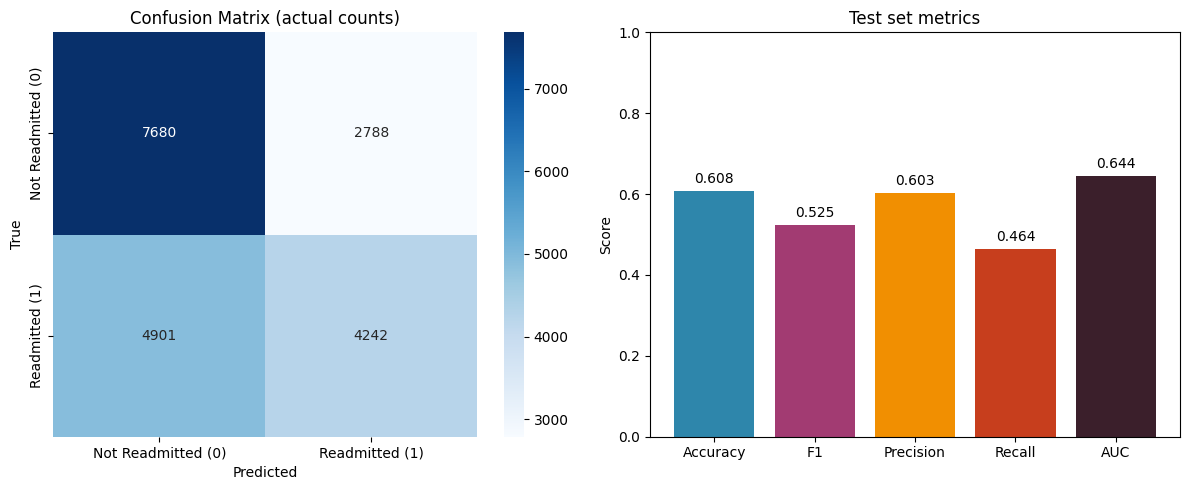

Test metrics: {'Accuracy': '0.6079', 'F1': '0.5246', 'Precision': '0.6034', 'Recall': '0.4640', 'AUC': '0.6438'}


In [8]:
# --- Code Block 3: Evaluation metrics and visualizations (Glucose Gang guide) ---

# 1. Confusion matrix with actual patient counts (e.g. True Negatives ~3593 in guide)
y_test_np = np.asarray(y_test)
cm = confusion_matrix(y_test, y_test_pred)
labels_binary = ["Not Readmitted (0)", "Readmitted (1)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_binary, yticklabels=labels_binary, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (actual counts)")

# 2. Metrics: Accuracy, F1, Precision, Recall, AUC
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
auc = roc_auc_score(y_test, final_clf.predict_proba(X_test)[:, 1]) if hasattr(final_clf, "predict_proba") else 0.0

metrics = {"Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec, "AUC": auc}
axes[1].bar(metrics.keys(), metrics.values(), color=["#2e86ab", "#a23b72", "#f18f01", "#c73e1d", "#3b1f2b"])
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].set_title("Test set metrics")
for k, v in metrics.items():
    axes[1].text(list(metrics.keys()).index(k), v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
print("Test metrics:", {k: f"{v:.4f}" for k, v in metrics.items()})

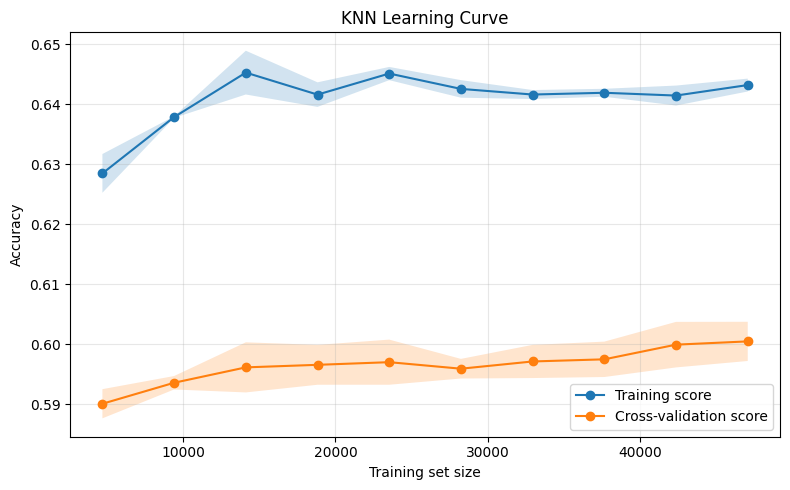

In [9]:
# Learning curve: Training score vs Cross-validation score
train_sizes, train_scores, cv_scores = learning_curve(
    final_clf, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
cv_mean = cv_scores.mean(axis=1)
cv_std = cv_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.2)
plt.plot(train_sizes, train_mean, "o-", label="Training score")
plt.plot(train_sizes, cv_mean, "o-", label="Cross-validation score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.title("KNN Learning Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Improved KNN: class balancing + distance weighting

To improve minority-class recall (<30 and >30), we (1) **oversample** minority classes in the training set so the classifier sees more balanced labels, and (2) use **distance-weighted** KNN so closer neighbors count more than distant ones.

In [10]:
# Balanced training set: oversample minority classes to match majority count (training only)
def oversample_train(X_train, y_train, random_state=42):
    rng = np.random.default_rng(random_state)
    y_ = np.asarray(y_train)
    classes = np.unique(y_)
    counts = {c: np.sum(y_ == c) for c in classes}
    max_count = max(counts.values())
    X_list, y_list = [], []
    for c in classes:
        idx = np.where(y_ == c)[0]
        n_sample = max_count
        idx_resampled = rng.choice(idx, size=n_sample, replace=(counts[c] < max_count))
        X_list.append(X_train[idx_resampled])
        y_list.append(y_[idx_resampled])
    return np.vstack(X_list), np.concatenate(y_list)

X_train_bal, y_train_bal = oversample_train(X_train, y_train, random_state=RANDOM_STATE)
print("Original train:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Balanced train:", dict(zip(*np.unique(y_train_bal, return_counts=True))))

Original train: {np.int64(0): np.int64(31402), np.int64(1): np.int64(27429)}
Balanced train: {np.int64(0): np.int64(31402), np.int64(1): np.int64(31402)}


In [11]:
# KNN: k search on balanced training + distance weighting (validation unchanged)
k_values_improved = [1, 3, 5, 7, 9, 11, 15, 21, 25, 31]
best_k_improved = None
best_val_acc_improved = 0.0
results_improved = []

for k in k_values_improved:
    clf = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    clf.fit(X_train_bal, y_train_bal)
    y_val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    results_improved.append((k, val_acc))
    if val_acc > best_val_acc_improved:
        best_val_acc_improved = val_acc
        best_k_improved = k

print("Improved (balanced + distance) validation accuracy per k:")
for k, acc in results_improved:
    print(f"  k={k}: {acc:.4f}")
print(f"\nBest k: {best_k_improved} (validation accuracy: {best_val_acc_improved:.4f})")

Improved (balanced + distance) validation accuracy per k:
  k=1: 0.5555
  k=3: 0.5608
  k=5: 0.5648
  k=7: 0.5710
  k=9: 0.5739
  k=11: 0.5799
  k=15: 0.5838
  k=21: 0.5902
  k=25: 0.5900
  k=31: 0.5951

Best k: 31 (validation accuracy: 0.5951)


In [12]:
# Final model: evaluate on test set
final_clf_improved = KNeighborsClassifier(n_neighbors=best_k_improved, weights="distance", n_jobs=-1)
final_clf_improved.fit(X_train_bal, y_train_bal)
y_test_pred_improved = final_clf_improved.predict(X_test)
test_accuracy_improved = accuracy_score(y_test, y_test_pred_improved)
print(f"Improved — Test accuracy: {test_accuracy_improved:.4f}  (baseline was {test_accuracy:.4f})")
print("\nClassification report (improved, test set):")
print(classification_report(y_test, y_test_pred_improved))
print("Confusion matrix (improved, test set):")
print(confusion_matrix(y_test, y_test_pred_improved))

Improved — Test accuracy: 0.5993  (baseline was 0.6079)

Classification report (improved, test set):
              precision    recall  f1-score   support

           0       0.62      0.64      0.63     10468
           1       0.57      0.55      0.56      9143

    accuracy                           0.60     19611
   macro avg       0.60      0.60      0.60     19611
weighted avg       0.60      0.60      0.60     19611

Confusion matrix (improved, test set):
[[6715 3753]
 [4105 5038]]


In [13]:
# Compare baseline vs balanced model (macro F1 is often better for imbalanced data)
from sklearn.metrics import f1_score
macro_f1_baseline = f1_score(y_test, y_test_pred, average="macro")
macro_f1_improved = f1_score(y_test, y_test_pred_improved, average="macro")
print("Comparison (test set):")
print(f"  Accuracy:  baseline {test_accuracy:.4f}  |  improved {test_accuracy_improved:.4f}")
print(f"  Macro F1:  baseline {macro_f1_baseline:.4f}  |  improved {macro_f1_improved:.4f}")

Comparison (test set):
  Accuracy:  baseline 0.6079  |  improved 0.5993
  Macro F1:  baseline 0.5955  |  improved 0.5964


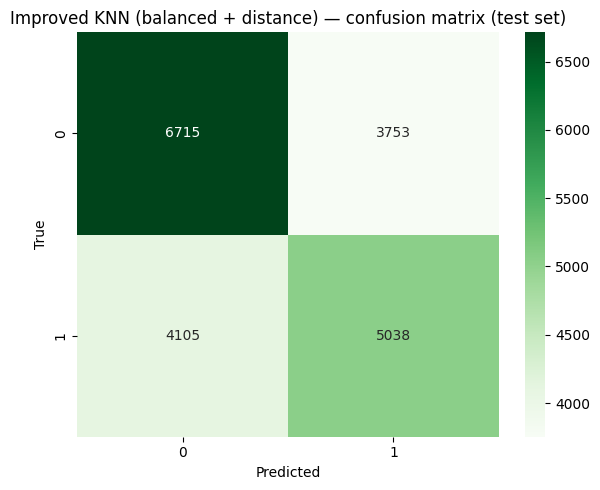

In [14]:
# Confusion matrix heatmap
classes = sorted(y_test.unique())
cm_improved = confusion_matrix(y_test, y_test_pred_improved)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_improved, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Improved KNN (balanced + distance) — confusion matrix (test set)")
plt.tight_layout()
plt.show()

## Visualizations

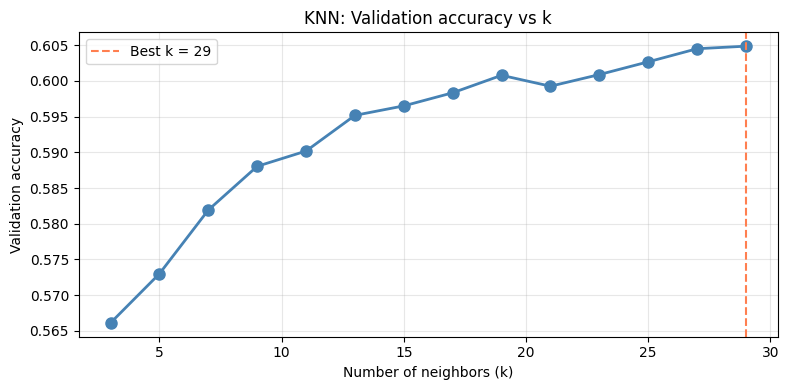

In [15]:
# Validation accuracy vs k (from GridSearchCV)
k_vals = [p["n_neighbors"] for p in grid.cv_results_["params"]]
val_accs = grid.cv_results_["mean_test_score"]
plt.figure(figsize=(8, 4))
plt.plot(k_vals, val_accs, "o-", color="steelblue", linewidth=2, markersize=8)
plt.axvline(x=best_k, color="coral", linestyle="--", label=f"Best k = {best_k}")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Validation accuracy")
plt.title("KNN: Validation accuracy vs k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

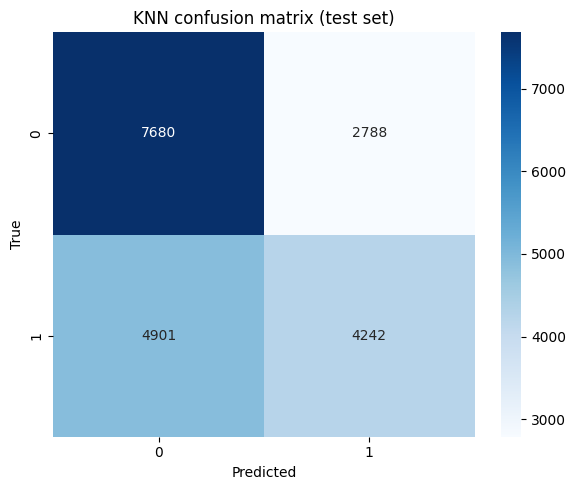

In [16]:
import seaborn as sns# 1. Validation accuracy vs k (hyperparameter search)

# 2. Confusion matrix heatmap (test set)
cm = confusion_matrix(y_test, y_test_pred)
classes = sorted(y_test.unique())  # <30, >30, NO
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("KNN confusion matrix (test set)")
plt.tight_layout()
plt.show()

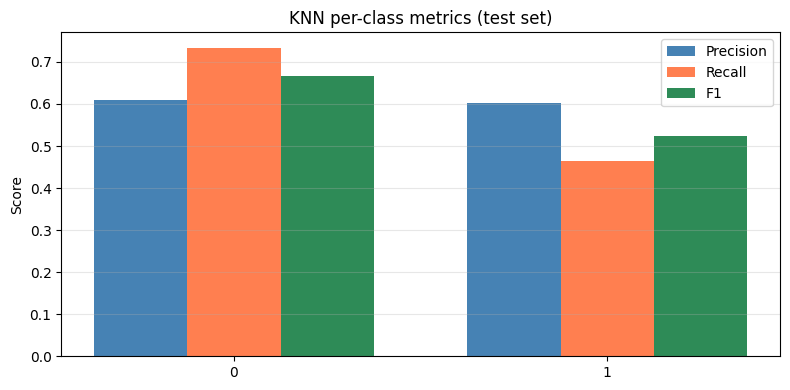

In [18]:
# 3. Per-class precision, recall, F1 (test set)
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, labels=classes)
x = np.arange(len(classes))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, precision, width, label="Precision", color="steelblue")
ax.bar(x, recall, width, label="Recall", color="coral")
ax.bar(x + width, f1, width, label="F1", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Score")
ax.set_title("KNN per-class metrics (test set)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()